In [1]:
import os
import sys
src_dir = os.path.join(os.getcwd(), '..', 'src' )
sys.path.append(src_dir)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("predict-future-sales.csv")
df

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city
0,2013-01-02,0.0,59.0,22154.0,999.00,1.0,явление 2012 (bd),37.0,кино - blu-ray,"ярославль тц ""альтаир""",ярославль
1,2013-01-03,0.0,25.0,2552.0,899.00,1.0,deep purple the house of blue light lp,58.0,музыка - винил,"москва трк ""атриум""",москва
2,2013-01-05,0.0,25.0,2552.0,899.00,0.0,deep purple the house of blue light lp,58.0,музыка - винил,"москва трк ""атриум""",москва
3,2013-01-06,0.0,25.0,2554.0,1709.05,1.0,deep purple who do you think we are lp,58.0,музыка - винил,"москва трк ""атриум""",москва
4,2013-01-15,0.0,25.0,2555.0,1099.00,1.0,deep purple 30 very best of 2cd (фирм.),56.0,музыка - cd фирменного производства,"москва трк ""атриум""",москва
...,...,...,...,...,...,...,...,...,...,...,...
2935838,2015-10-10,33.0,25.0,7409.0,299.00,1.0,v/a nu jazz selection (digipack),55.0,музыка - cd локального производства,"москва трк ""атриум""",москва
2935839,2015-10-09,33.0,25.0,7460.0,299.00,1.0,v/a the golden jazz collection 1 2cd,55.0,музыка - cd локального производства,"москва трк ""атриум""",москва
2935840,2015-10-14,33.0,25.0,7459.0,349.00,1.0,v/a the best of the 3 tenors,55.0,музыка - cd локального производства,"москва трк ""атриум""",москва
2935841,2015-10-22,33.0,25.0,7440.0,299.00,1.0,v/a relax collection planet mp3 (mp3-cd) (jewel),57.0,музыка - mp3,"москва трк ""атриум""",москва


In [3]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week
df['day_of_week'] = df['date'].dt.day_of_week
df['period'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
df


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city,year,month,week,day_of_week,period
0,2013-01-02,0.0,59.0,22154.0,999.00,1.0,явление 2012 (bd),37.0,кино - blu-ray,"ярославль тц ""альтаир""",ярославль,2013,1,1,2,2013-01
1,2013-01-03,0.0,25.0,2552.0,899.00,1.0,deep purple the house of blue light lp,58.0,музыка - винил,"москва трк ""атриум""",москва,2013,1,1,3,2013-01
2,2013-01-05,0.0,25.0,2552.0,899.00,0.0,deep purple the house of blue light lp,58.0,музыка - винил,"москва трк ""атриум""",москва,2013,1,1,5,2013-01
3,2013-01-06,0.0,25.0,2554.0,1709.05,1.0,deep purple who do you think we are lp,58.0,музыка - винил,"москва трк ""атриум""",москва,2013,1,1,6,2013-01
4,2013-01-15,0.0,25.0,2555.0,1099.00,1.0,deep purple 30 very best of 2cd (фирм.),56.0,музыка - cd фирменного производства,"москва трк ""атриум""",москва,2013,1,3,1,2013-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935838,2015-10-10,33.0,25.0,7409.0,299.00,1.0,v/a nu jazz selection (digipack),55.0,музыка - cd локального производства,"москва трк ""атриум""",москва,2015,10,41,5,2015-10
2935839,2015-10-09,33.0,25.0,7460.0,299.00,1.0,v/a the golden jazz collection 1 2cd,55.0,музыка - cd локального производства,"москва трк ""атриум""",москва,2015,10,41,4,2015-10
2935840,2015-10-14,33.0,25.0,7459.0,349.00,1.0,v/a the best of the 3 tenors,55.0,музыка - cd локального производства,"москва трк ""атриум""",москва,2015,10,42,2,2015-10
2935841,2015-10-22,33.0,25.0,7440.0,299.00,1.0,v/a relax collection planet mp3 (mp3-cd) (jewel),57.0,музыка - mp3,"москва трк ""атриум""",москва,2015,10,43,3,2015-10


# 1. General Distributions

## 1.1 *item_cnt_day* distribution

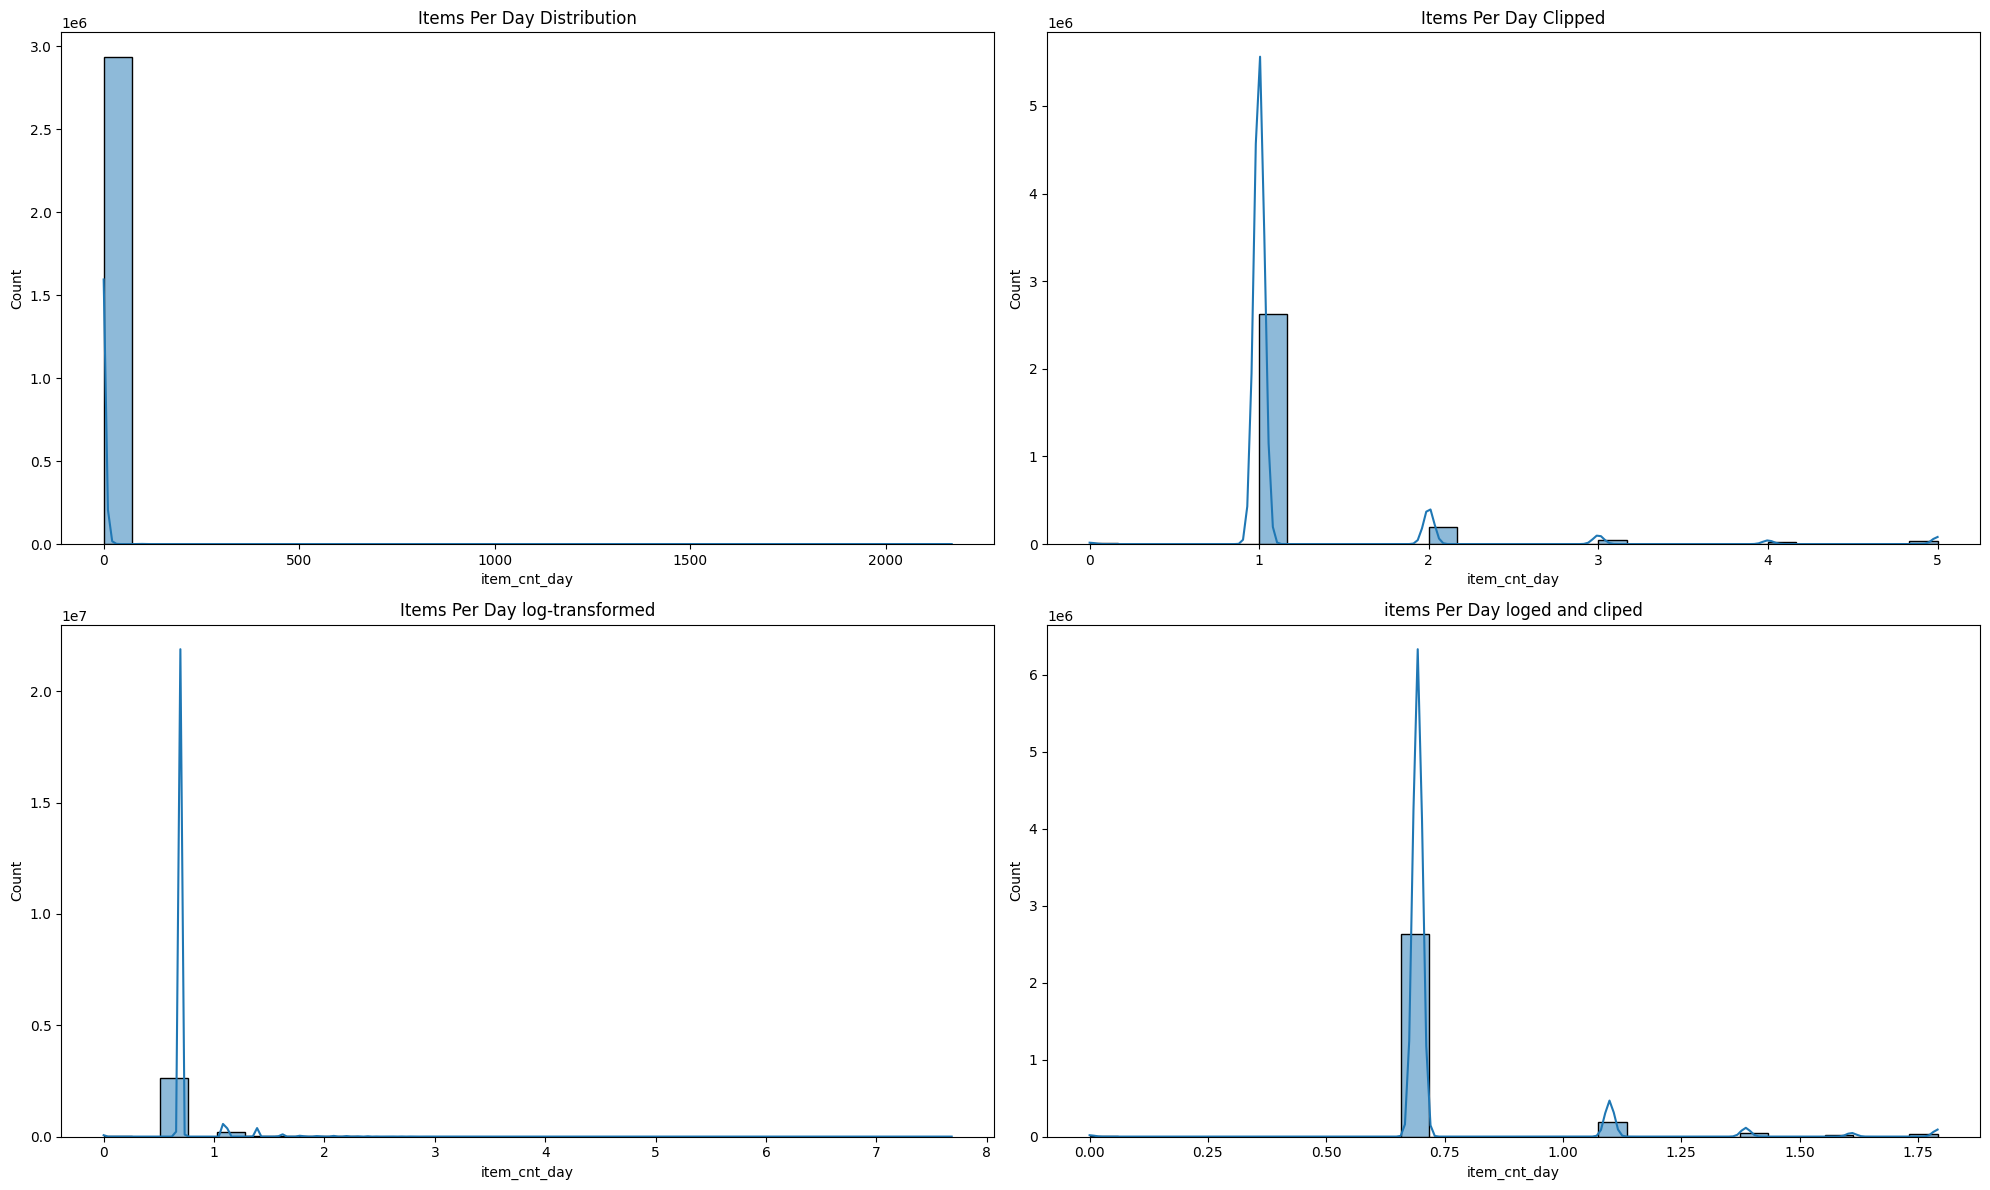

In [4]:
fig, axes = plt.subplots(2, 2, figsize = (20,12))

sns.histplot(df['item_cnt_day'], bins=30, ax=axes[0,0], kde=True)
axes[0,0].set_title('Items Per Day Distribution')

upper_bound = df['item_cnt_day'].quantile(0.99)

sns.histplot(df['item_cnt_day'].clip(0, upper_bound), bins=30, ax=axes[0,1], kde=True)
axes[0,1].set_title('Items Per Day Clipped')

sns.histplot(np.log1p(df['item_cnt_day']), bins=30, ax=axes[1,0], kde=True)
axes[1,0].set_title('Items Per Day log-transformed')

sns.histplot(np.log1p(df['item_cnt_day'].clip(0, upper_bound)), bins=30, ax=axes[1,1], kde=True)
axes[1,1].set_title('items Per Day loged and cliped')

plt.tight_layout()
plt.show()

Observations
- General *item_cnt_day* distribution doesn't seem to be very informative, though we can see that it is extremelly skewed. Most of items are sold less than ~50 units per day and there's a long tail up to more than 2000 units per day. What we can learn is that perhaps there are special days when sales go extremely up(like promotions, discounts or holidays)
- The idea is to clip the data to high upper bound percentile(99%). From here we learn that mostle items are sold 1 unit per day (around 2.7kk entries), nevertheless we have those items with zero-sells, an amount of items sold twice a day (around 200k entries) and very few items sold >3 units per day. The main conclusion is that the most common transactions are 1 item per day.
- Let's try log-transformation. This is done to compress the difference between qunatity of items sold. In normal representation the difference between 1 item per day and 2000 items per day is 1999, but after log-transformation the difference ~7.60. From here we learn that the most common logarithm is in range (0,1), this means that most of items are sold less then 2.7 units per day. Though it's a little pea at log value a bit more than 1, representing those items sold about 3 units a day.
- The last but not least is using both log-transformation and cliping. The most common logarithm is nearly 0.75, which says that items are usually sold 2 units per day. There's also a little peak at logarithm of about 1.1, representing items sold 3 units per day.

From here we can make a general conclusion - mostly items are sold 1-3 units per day. Nevertheless there are those which are not sold at all and those sold in extremely high amounts (may be holidays or whatever)



**Feature Engineering Ideas**
- As we saw really large values of *item_cnt_day* (~2000) it makes sense to standardize this feature. The idea coming to my ming is to log-transfrom and then scale to [0,1] range (via MinMaxScaler or StandardScaler). This way the model would not try to figure out those extreme sales and will be prevented from overfiting. Moreover tree-like models and neural networks are more preferable to be trained on scaled data.
- Also I guess some time-series analysis will help figure out whether those high extreme values are something seasonal/periodical or just some stochastic events. If the first option, then some kind of indicator *is_holiday* (or whatever) can be found usefull

## 1.2 *item_price* distribution

Now I guess it might be useful to analyse the distribution of item prices so as to see potential patterns or may be think of some feature engineering

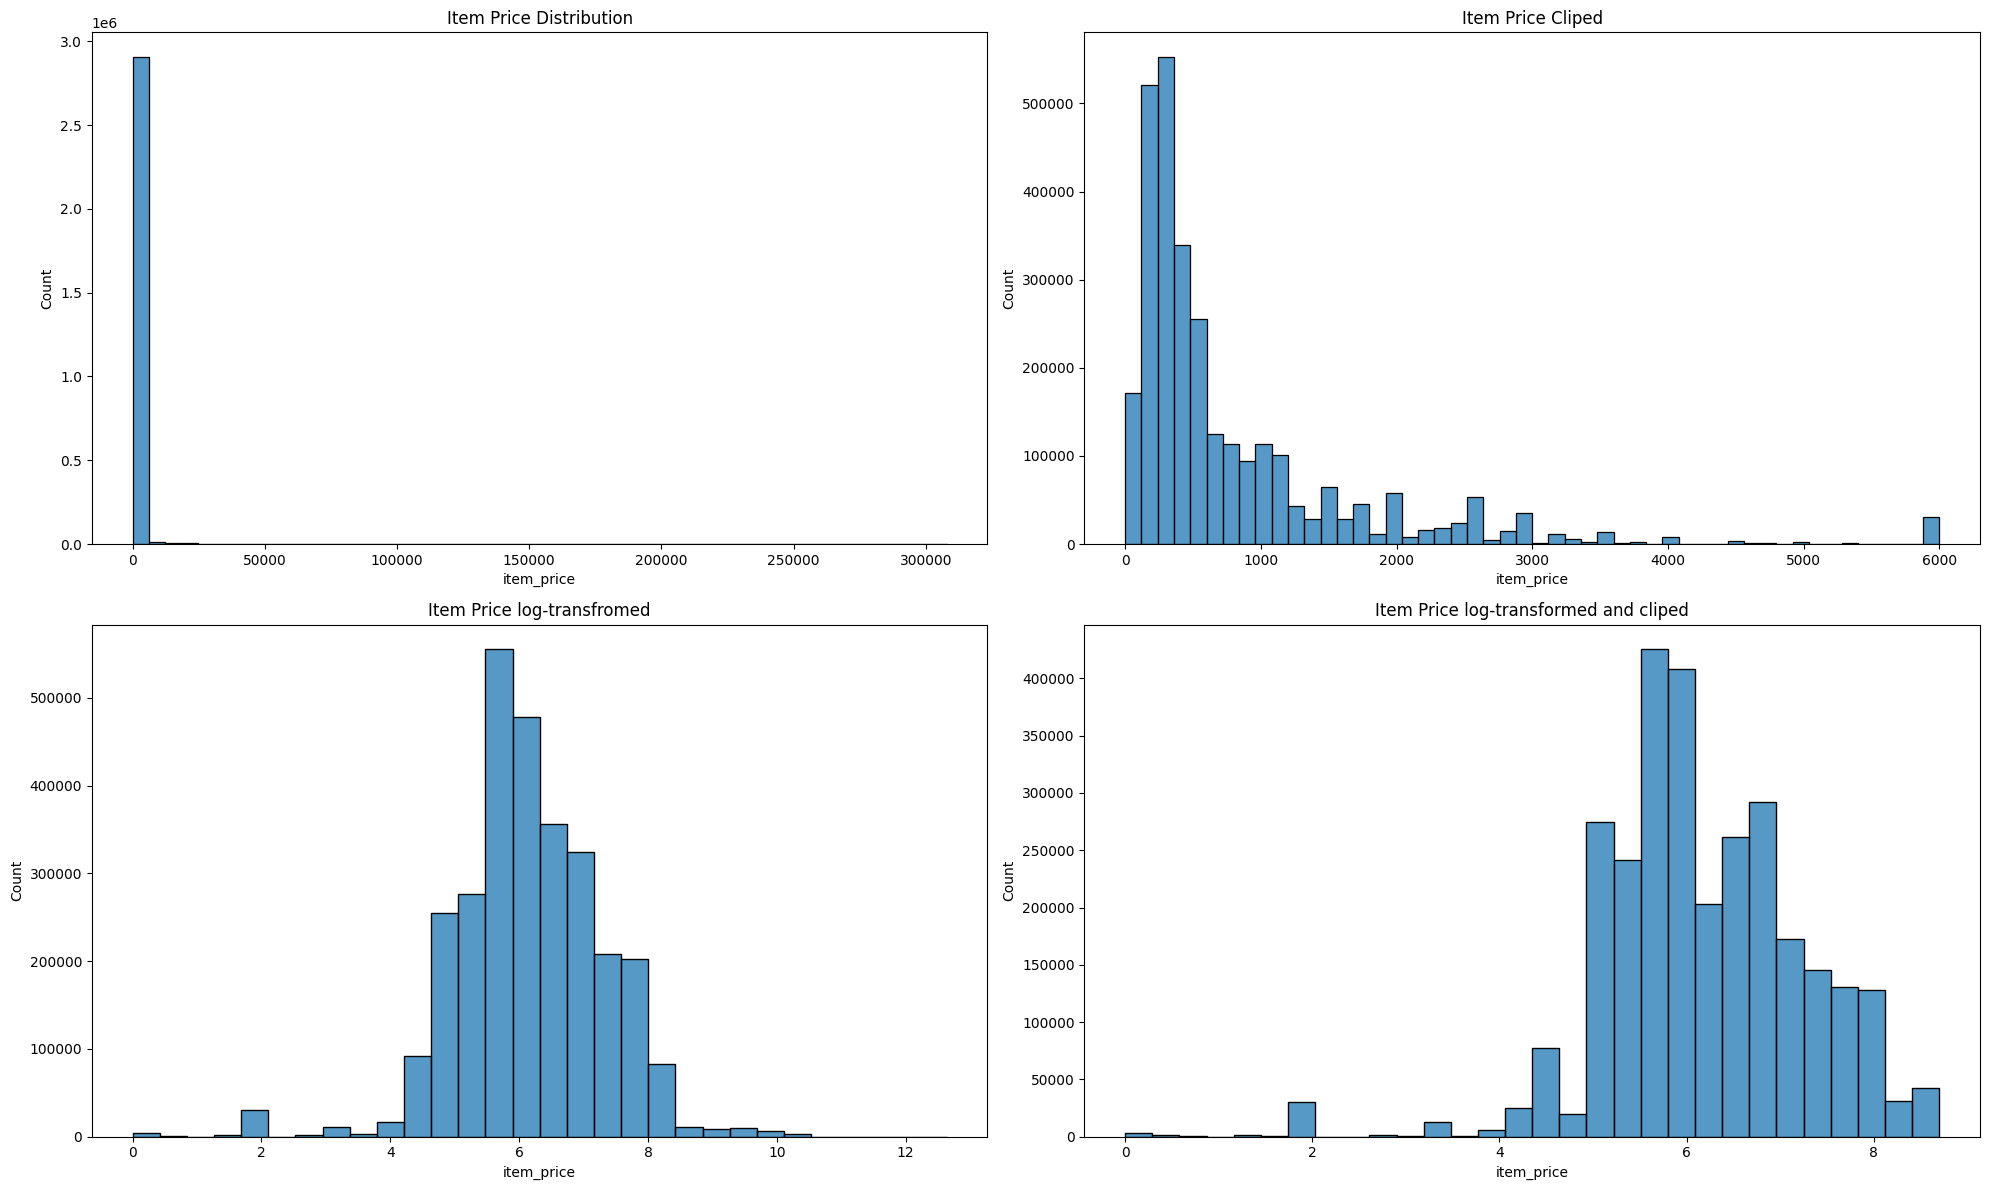

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(20,12))
upper_bound = df['item_price'].quantile(0.99)

sns.histplot(df['item_price'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Item Price Distribution')

sns.histplot(df['item_price'].clip(0, upper_bound), bins=50, ax=axes[0,1])
axes[0,1].set_title('Item Price Cliped')

sns.histplot(np.log1p(df['item_price']), bins=30, ax=axes[1,0])
axes[1,0].set_title('Item Price log-transfromed')

sns.histplot(np.log1p(df['item_price'].clip(0, upper_bound)), bins=30, ax=axes[1,1])
axes[1,1].set_title('Item Price log-transformed and cliped')

plt.tight_layout()
plt.show()

In [6]:
2.7 ** 4, 2.7 **8

(53.144100000000016, 2824.2953648100015)

Observations:
- General *item_price* does not give us much information as well. Though, we can see that most items' price is under 10k, but there is a little spike around 25k. Neverthell the distribution is very skewed and the prices go up to 300k, which is abnormal.
- Clipping shows that 99% of items cost less than 6k. There is a huge spike at about 250-375 units, another spike at about 500-625, a group of prices uniformly distributed from ~650 up to ~1300. We can see another small groups but the main observation here is that prices mostly are not higher than 3k.
- Logarithm shows us a huge group of items with logarithm of about 5.75 - 6.25, representing price range of 300-500. The next big group is logarithm of 6.4 - 7.2, representing price range of about 550-1300. Another big group is logarithm of 4.5 - 5.5, representing price range of about 80 - 250. Yet there are still some more small groups and a strange spike at about 0 logarithm.
- Clipping and log-transfromation reveals some important information - the main range of item prices is about 50-3000. All the other stuff seems a bit strange and is probably outliers (or may be some luxurious or vise versa free items).

From here we can make a general conclusion: despite the fact the the maximum price is around 300k, the most common prices are in range of 50-3k. Thus it gives the motivation to check the correlation between the *item_cnt_day* and *item_price*, supposely items with lower price can be sold more often.

**Feature Engineering Ideas**
- As it was observed prices are somehow 'clustered' and it may be useful to divide them into categorical groups(e.g. low, meidum, high, luxury), which might be a goo indicator
- It makes sense to transform prices, i.e. apply log-transformation and scaling(via MinMaxScaler or StandardScaler). As it was mentioned before, this will reduce the overfitting effect and will simplify optimization

# 2. *item_cnt_day* - *item_price* correlation
It might be useful to understand whether the *item_cnt_day* is really dependent on *item_price*

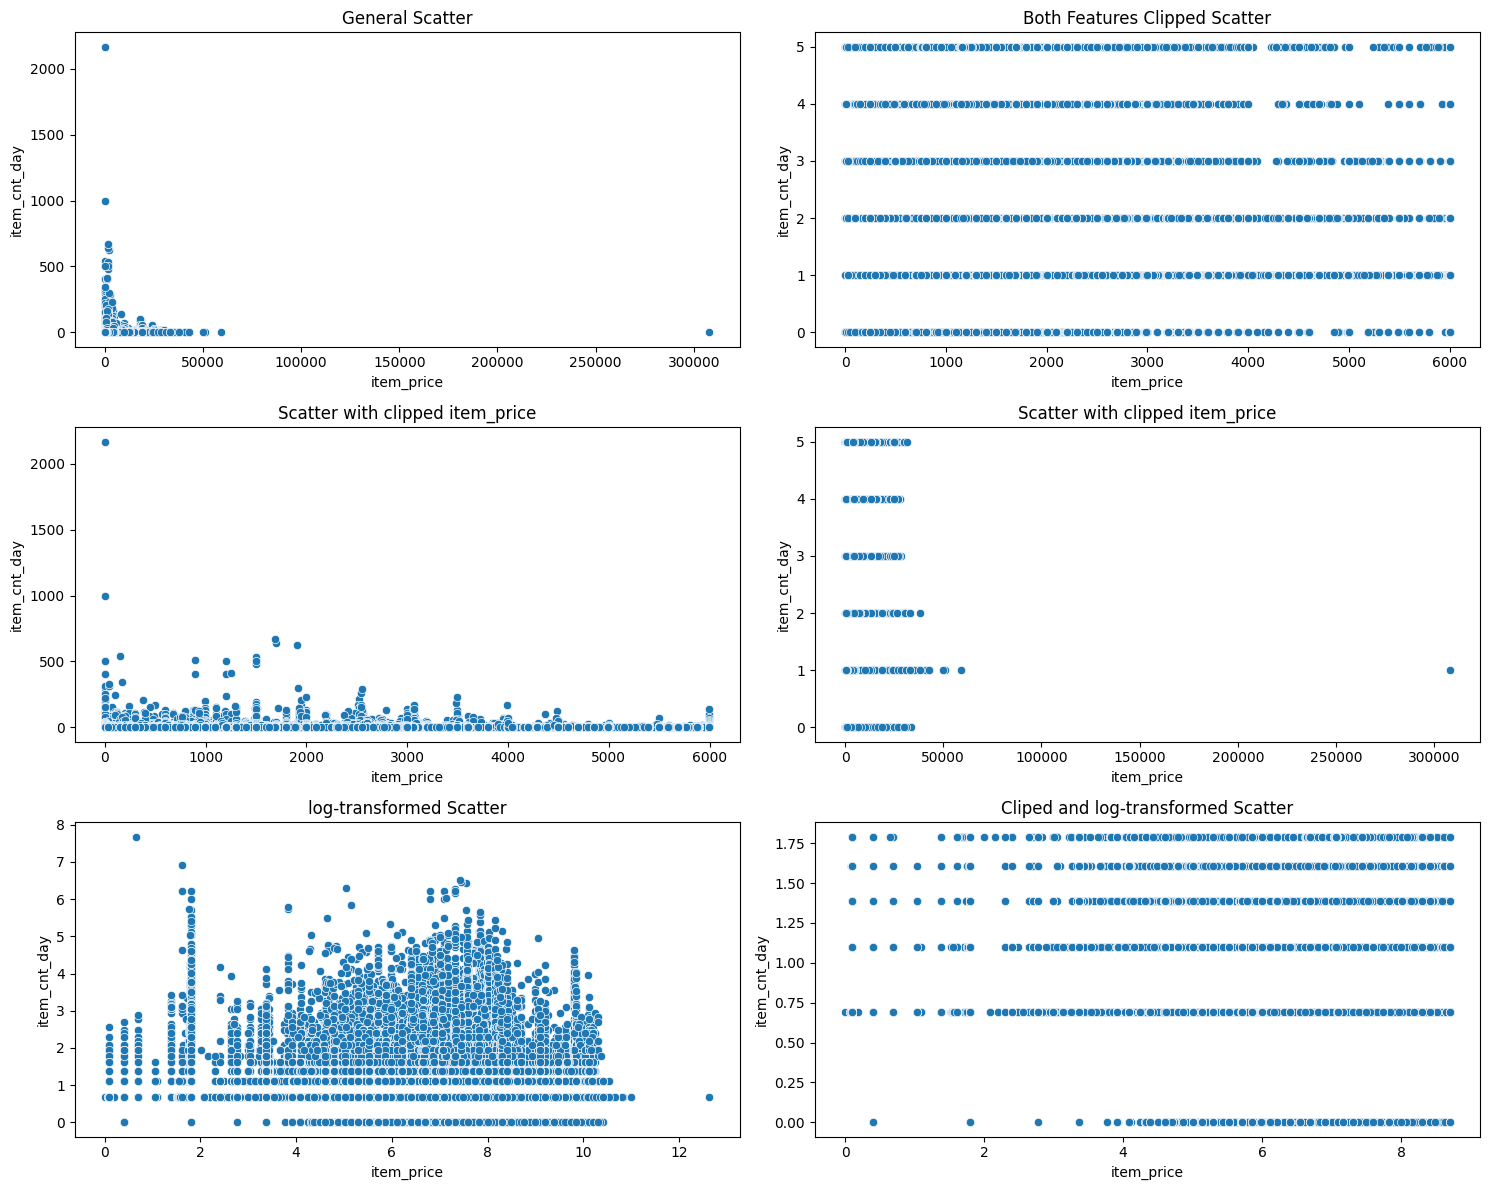

In [7]:
fig, axes = plt.subplots(3, 2, figsize = (15,12))
upper_bound_items, upper_bound_price = df['item_cnt_day'].quantile(0.99), df['item_price'].quantile(0.99)

sns.scatterplot(x=df['item_price'], y=df['item_cnt_day'], ax=axes[0,0])
axes[0,0].set_title('General Scatter')

sns.scatterplot(x=df['item_price'].clip(0, upper_bound_price), y=df['item_cnt_day'].clip(0, upper_bound_items), ax=axes[0,1])
axes[0,1].set_title('Both Features Clipped Scatter')

sns.scatterplot(x=df['item_price'].clip(0, upper_bound_price), y=df['item_cnt_day'], ax=axes[1,0])
axes[1,0].set_title('Scatter with clipped item_price')

sns.scatterplot(x=df['item_price'], y=df['item_cnt_day'].clip(0, upper_bound_items), ax=axes[1,1])
axes[1,1].set_title('Scatter with clipped item_price')

sns.scatterplot(x=np.log1p(df['item_price']), y=np.log1p(df['item_cnt_day']), ax=axes[2,0])
axes[2,0].set_title('log-transformed Scatter')

sns.scatterplot(x=np.log1p(df['item_price'].clip(0, upper_bound_price)), y=np.log1p(df['item_cnt_day'].clip(0, upper_bound_items)), ax=axes[2,1])
axes[2,1].set_title('Cliped and log-transformed Scatter')

plt.tight_layout()
plt.show()

Observation:
- Looking at general scatter we can make an assumption that there is really some kind of correlation between *item_price* and *item_cnt_day*. Small prices tend to be dominant and here we can see that most of items are compressed by 50k range. But there is one strange thing: 60k-300k range seems to be empty hmmmm???
- Clipping both features to their 99% percentiles does not show any specific correlations. May be it makes sense to clip features separately.
- Cliping price only reveals some interesting things. First of all we can see 2 extraordinary points near zero-price with high value of items bought (>2k and 1k). Moreover it's clearly seen that items with lower price (below 2k) tend to be bought more often. Then, they are dependent hmmm???
- Cliping *item_cnt_day* separately gives totally no information, therefore we can skip this scatter :)
- 2 final plots don't reveal any specific information as well

General conclusion is that there is no highly contrasted correlation (may be it's hidden) between *item_cnt_day* and *item_price*, except for the fact that items which cost less than 2k are more likely to be bought.

# 3. Time Series Research
It's now time for one of the most interesting parts - anlyzing those strange extreme sales. General preassumption is that we are likely to have some special days (like holidays) when sales tend to go up.

First I'd love to know is there any changes in overall sales throughout time. Therefore doing `groupby` by *period* and summarizing *item_cnt_day* 

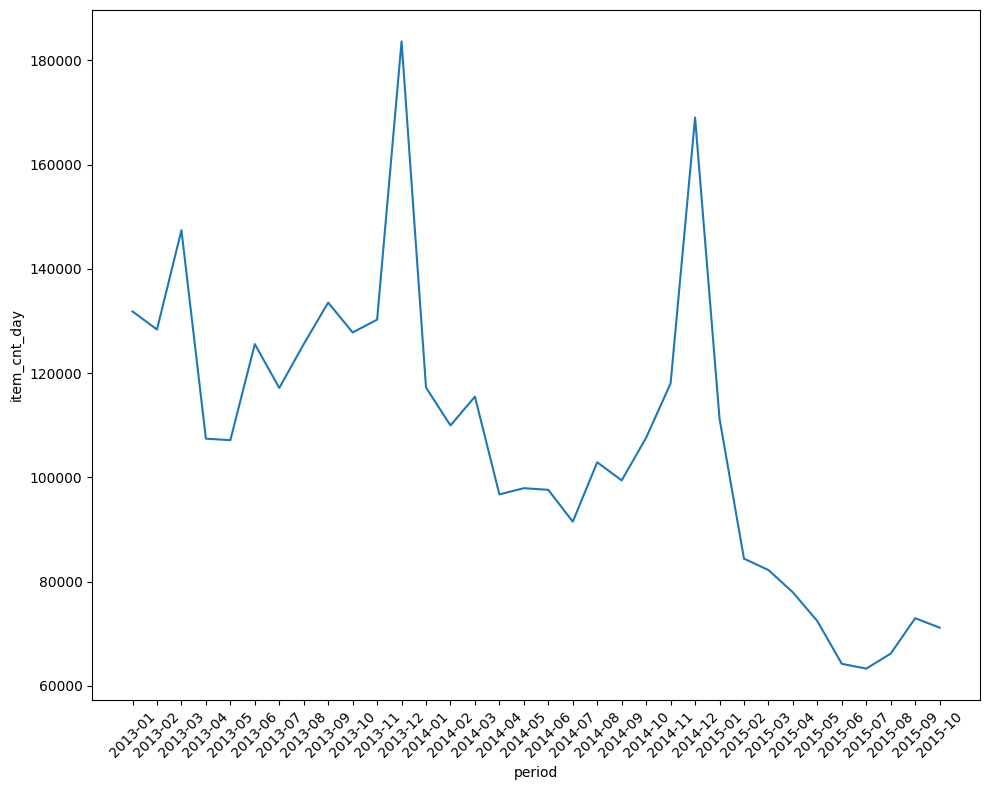

In [8]:
plt.figure(figsize=(10,8))
monthly_sales = df.groupby(['period']).agg({
    'item_cnt_day': 'sum'
}).reset_index()
sns.lineplot(x=monthly_sales['period'], y=monthly_sales['item_cnt_day'])
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

The initial time series analisis gives us some portion of interesting information
Observation:
- The start point is January 2013 and we can see that sales were about 130k items per month (all shops and all items), the end point is October 2015 and sales are about only 70k items per month. Obviously that the sales dramatically decreased. So for now we can suppose that generally sales tend to go down.
- Probably the most important thing we can admit is those high peaks in October-november. There are probably a lot of holidays at this period therefore it can be a bit obvious that sales go up, though it's very important information for us to know.
- Then we can observe those peaks in January-February, might be some holidays as well but in 2015 there was a decrease at this period which is strange. I prefere not to think that 2013 and 2014 had high sales at this period due to holidays.
- Sales tend to be relatively low in spring and seems like go down. 
- Sales tend to go up during summer, might be due to the fact of some vacations (or whatever).
- Winter is sort of a strange period, as somethings happens in december which makes sales go extremely low and I have no idea what it can be.

General conclusions: season of the year seems to be very important for us, as there are specific periods which tend to be repetitive.


**Feature Engineering Ideas**
- *month* might be very informative for us, but not for the model. We now know that sales tend to go extremely high in October-November, then go extremely low in December-January, and be relatively low during summer. The only problem is that we know that January goes wrigth after December, unfirtunattely the model will intepret December as 12 and January as 1. See, it's not obvious for the model that January goes right after December. Therefore I suppose we can benefit from circular month representation(i.e. sin and cos)
- We might need an indicatior os something like *is_holiday* for October-November period and *is_winter* for winter extreme decrease.

May be decomposing the time series might give us some external information

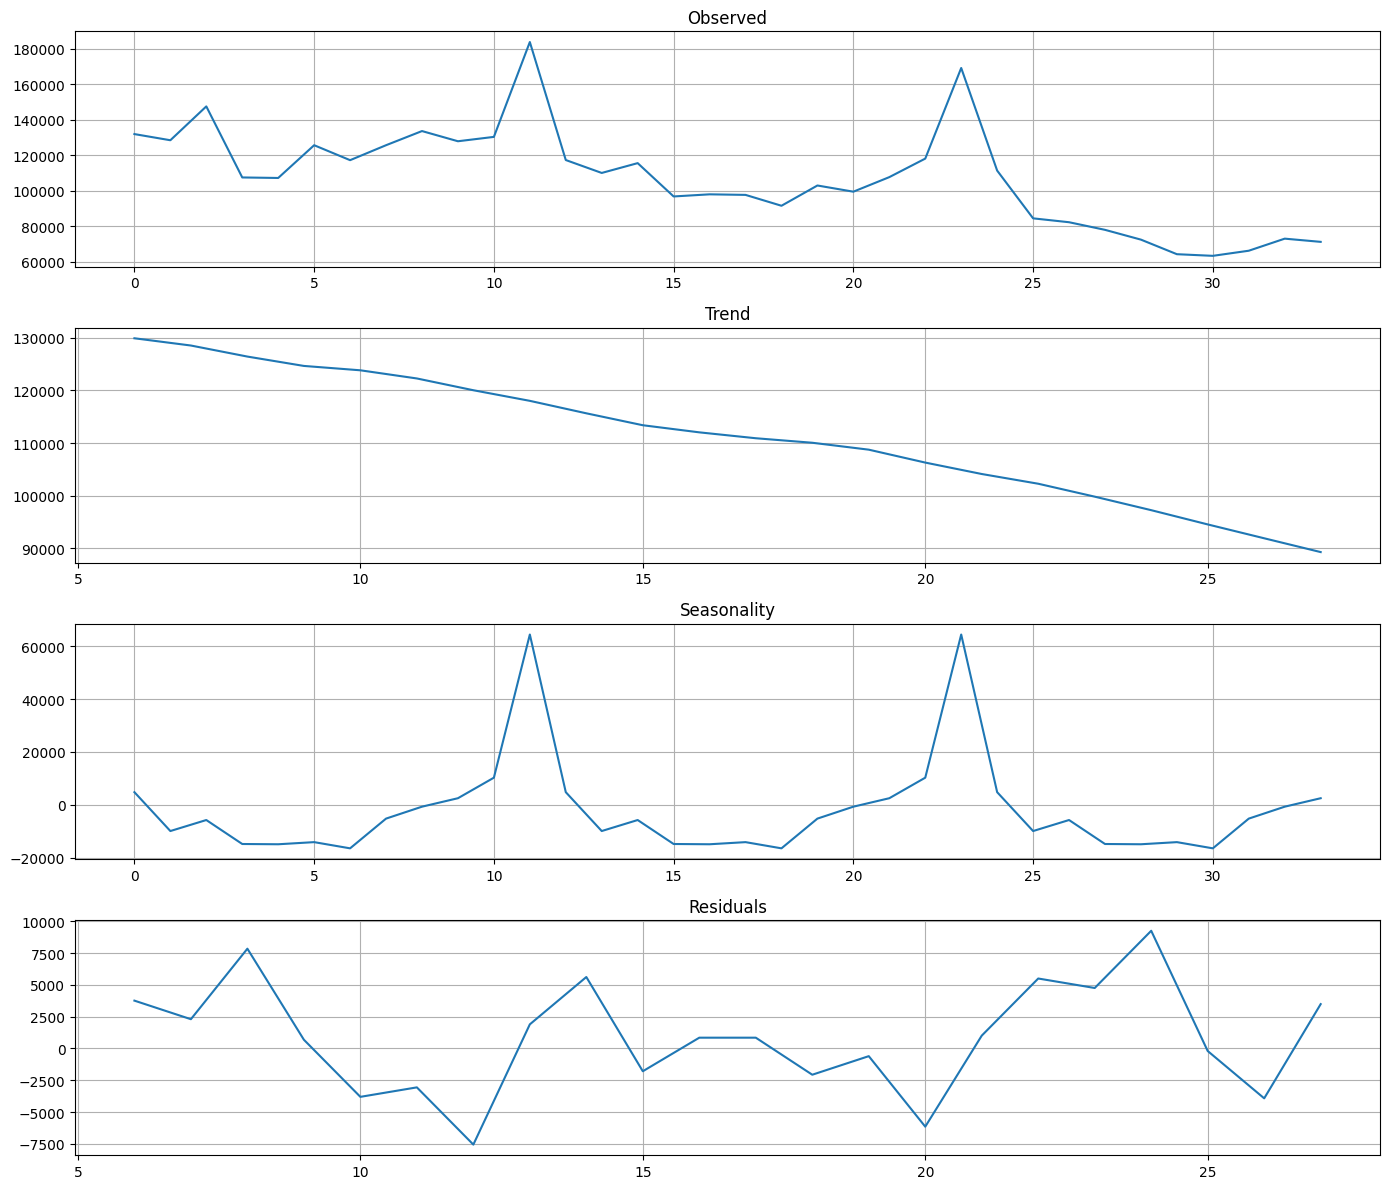

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(monthly_sales['item_cnt_day'], model='additive', period=12)
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality')
decomposition.resid.plot(ax=axes[3], title='Residuals')
for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()
